In [1]:
import sys
import os
from pathlib import Path

# Lấy đường dẫn tuyệt đối của thư mục 'Chat With Data'
# Vì file đang nằm trong 'notebooks/', ta lấy parent của thư mục hiện tại
root_path = str(Path(os.getcwd()).parent)

if root_path not in sys.path:
    sys.path.append(root_path)

print(f"✅ Đã kết nối Notebook với thư mục gốc: {root_path}")

✅ Đã kết nối Notebook với thư mục gốc: d:\Project\Chat With Data


In [2]:
import os

# Định nghĩa đường dẫn thư mục log
log_dir = r'd:\Project\Chat With Data\notebooks\logs'

# Nếu thư mục chưa tồn tại thì tự động tạo mới
if not os.path.exists(log_dir):
    os.makedirs(log_dir)
    print(f"Đã tạo thư mục: {log_dir}")

In [3]:
pwd

'd:\\Project\\Chat With Data\\notebooks'

# state

In [4]:
"""Tool functions and conditional-edge routing for the Hierarchical RAG pipeline.

Phân biệt với node.py:
  - Routing functions (route_after_*):  Trả về tên node tiếp theo — dùng cho
    add_conditional_edges trong StateGraph.
  - fan_out_subtasks:  Trả về danh sách Send objects để chạy subtask song song.
  - Tool nodes (rag_retriever, web_searcher, llm_node, pandas_runner):
    Nhận AgentState và write vào sub_task_answers / all_context.

Routing
-------
route_after_ambiguity  — Sau ambiguity_checker  : planner | rejection_handler
route_after_router     — Sau knowledge_router   : hyde | web_searcher | llm_node
route_after_validator  — Sau validator          : web_searcher | END

Fan-out
-------
fan_out_subtasks       — Sau planner            : Send × N → subtask_runner

Tool nodes
----------
rag_retriever          — Node 5a : LlamaIndex AutoMergingRetriever → all_context
web_searcher           — Node 5b : Tavily search → sub_task_answers
llm_node               — Node 5c : LLM direct knowledge → sub_task_answers
pandas_runner          — Node 5d : Pandas DataFrame agent → sub_task_answers
"""

import functools
from typing import Optional

import pandas as pd
from langgraph.graph import END
from langgraph.types import Send

from langchain_core.messages import HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults

from src.agents.state import AgentState
from src.prompt.template import PANDAS_AGENT_PREFIX, LLM_KNOWLEDGE_PROMPT
from src.llm.factory import LLLMFactory
from src.llm.embeddings import EmbeddingFactory
from src.retrieval.vector_db import VectorDBManager
from src.core.config import settings
from src.utils.logger import logger


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------


def _provider(state: AgentState) -> str:
    return state.get("llm_provider") or settings.llm.provider


def _get_llm(provider: str, purpose: str):
    """Return a plain LangChain chat LLM via LLLMFactory."""
    return LLLMFactory.create_client(purpose=purpose, provider=provider).get_llm()


def _get_vector_db(provider: str) -> VectorDBManager:
    """Instantiate VectorDBManager bound to the current provider’s embedding model."""
    embedding = EmbeddingFactory().get_embedding(provider=provider)
    return VectorDBManager(embedding_model=embedding, provider=provider)


# ---------------------------------------------------------------------------
# Routing — conditional edge functions
# ---------------------------------------------------------------------------


def route_after_ambiguity(state: AgentState) -> str:
    """Route after ambiguity_checker.

    Returns:
        "rejection_handler" when the question is ambiguous / off-topic.
        "planner"           when the question is clear and actionable.
    """
    if state.get("is_ambiguous"):
        logger.info("[route_after_ambiguity] → rejection_handler")
        return "rejection_handler"
    logger.info("[route_after_ambiguity] → planner")
    return "planner"


def route_after_router(state: AgentState) -> str:
    """Route after knowledge_router.

    Maps the route value to the correct tool entry-point node:
        "rag"           → "hyde"         (RAG path starts with HyDE expansion)
        "web"           → "web_searcher"
        "llm_knowledge" → "llm_node"
        "pandas"        → "pandas_runner"

    Falls back to "hyde" on unknown values.
    """
    route = state.get("route", "rag")
    mapping = {
        "rag": "hyde",
        "web": "web_searcher",
        "llm_knowledge": "llm_node",
        "pandas": "pandas_runner",
    }
    destination = mapping.get(route, "hyde")
    logger.info(f"[route_after_router] route={route} → {destination}")
    return destination


def route_after_validator(state: AgentState) -> str:
    """Route after validator.

    Returns:
        "web_searcher"  when context is insufficient (score < threshold).
        END             when context coverage is acceptable.
    """
    if not state.get("is_context_valid", False):
        logger.info(
            f"[route_after_validator] score={state.get('validation_score', 0):.2f} "
            "→ web_searcher (fallback)"
        )
        return "web_searcher"
    logger.info(
        f"[route_after_validator] score={state.get('validation_score', 0):.2f} → END"
    )
    return END


# ---------------------------------------------------------------------------
# Fan-out — spawn one subtask_runner per sub-task
# ---------------------------------------------------------------------------


def fan_out_subtasks(state: AgentState):
    """Convert sub_tasks list into parallel Send objects.

    Each Send injects the current sub-task string into `current_task`
    so that the subtask subgraph sees exactly one task to process.

    Returns:
        List[Send] — one entry per sub-task; LangGraph executes them in parallel.
    """
    sub_tasks = state.get("sub_tasks") or []
    if not sub_tasks:
        logger.warning("[fan_out_subtasks] No sub-tasks found — falling back to raw question.")
        sub_tasks = [state.get("question", "")]

    sends = [
        Send("subtask_runner", {**state, "current_task": task})
        for task in sub_tasks
    ]
    logger.info(f"[fan_out_subtasks] Dispatching {len(sends)} subtask(s).")
    return sends


# ---------------------------------------------------------------------------
# Node 5a — RAG Retriever
# ---------------------------------------------------------------------------


def rag_retriever(state: AgentState) -> dict:
    """Retrieve relevant context chunks from the vector store (LlamaIndex).

    Uses AutoMergingRetriever for hierarchical parent/child merging.
    Query is the HyDE-expanded query if available, otherwise current_task.

    Reads:  hyde_query | current_task, collection_name, llm_provider
    Writes: all_context (appended via reducer)
    """
    provider = _provider(state)
    query = state.get("hyde_query") or state.get("current_task", "")
    collection_name = state.get("collection_name") or settings.storage.collection_name

    try:
        vdb = _get_vector_db(provider)
        retriever = vdb.get_retriever(
            similarity_top_k=settings.retrieval.top_k,
            collection_name=collection_name,
        )

        if retriever is None:
            logger.warning("[rag_retriever] Retriever unavailable — empty index?")
            return {"all_context": []}

        nodes = retriever.retrieve(query)
        chunks = [node.get_content() for node in nodes if node.get_content().strip()]

        logger.info(f"[rag_retriever] Retrieved {len(chunks)} chunk(s) for: {query[:60]}")
        return {"all_context": chunks}

    except Exception as e:
        logger.error(f"[rag_retriever] Error: {e}")
        return {"all_context": []}


# ---------------------------------------------------------------------------
# Node 5b — Web Searcher
# ---------------------------------------------------------------------------


def web_searcher(state: AgentState) -> dict:
    """Search the web via Tavily and append results to sub_task_answers.

    Activated either directly (route="web") or as RAG fallback when
    the validator scores context too low.

    Reads:  current_task, llm_provider
    Writes: sub_task_answers (appended via reducer)
    """
    query = state.get("current_task", "")

    try:
        tool = TavilySearchResults(max_results=5)
        results = tool.invoke(query)

        if not results:
            logger.warning("[web_searcher] No results returned from Tavily.")
            return {"sub_task_answers": [f"Không tìm thấy kết quả cho: {query}"]}

        # Format results into a readable block
        snippets = []
        for item in results:
            title = item.get("title", "")
            url = item.get("url", "")
            content = item.get("content", "")
            snippets.append(f"**{title}**\n{content}\n({url})")

        merged = "\n\n".join(snippets)
        answer = f"### Kết quả web search cho: _{query}_\n\n{merged}"

        logger.info(f"[web_searcher] {len(snippets)} result(s) retrieved.")
        return {"sub_task_answers": [answer]}

    except Exception as e:
        logger.error(f"[web_searcher] Error: {e}")
        return {"sub_task_answers": [f"Lỗi khi tìm kiếm: {e}"]}


# ---------------------------------------------------------------------------
# Node 5c — LLM Knowledge Node
# ---------------------------------------------------------------------------


def llm_node(state: AgentState) -> dict:
    """Answer the sub-task directly from the LLM's internal knowledge.

    Used when knowledge_router routes to "llm_knowledge" — typically for
    general questions that don't require retrieval.

    Reads:  current_task, llm_provider
    Writes: sub_task_answers (appended via reducer)
    """
    provider = _provider(state)
    task = state.get("current_task", "")

    prompt = LLM_KNOWLEDGE_PROMPT.format(current_task=task)

    try:
        llm = _get_llm(provider, "rag")
        response = llm.invoke(prompt)
        answer = response.content.strip()

        logger.info(f"[llm_node] Answered from LLM knowledge: {task[:60]}")
        return {"sub_task_answers": [answer]}

    except Exception as e:
        logger.error(f"[llm_node] Error: {e}")
        return {"sub_task_answers": [f"[llm_node] Lỗi: {e}"]}


# ---------------------------------------------------------------------------
# Node 5d — Pandas Runner
# ---------------------------------------------------------------------------


def pandas_runner(state: AgentState, df: Optional[pd.DataFrame] = None) -> dict:
    """Run tabular analysis using a Pandas DataFrame agent.

    `df` is injected at graph-build time via functools.partial (it lives in
    Streamlit session_state, not in LangGraph State).

    Reads:  current_task, llm_provider
    Writes: sub_task_answers (appended), chart_path (if chart was produced)
    """
    from langchain_experimental.agents import create_pandas_dataframe_agent

    task = state.get("current_task", "")
    provider = _provider(state)

    if df is None:
        logger.warning("[pandas_runner] No DataFrame injected — skipping.")
        return {"sub_task_answers": ["[pandas] Không có dữ liệu bảng để phân tích."]}

    try:
        llm = _get_llm(provider, "rag")
        
        # Generate a unique path for the chart
        import uuid
        charts_dir = Path("output_charts")
        charts_dir.mkdir(exist_ok=True)
        target_chart_path = charts_dir / f"chart_{uuid.uuid4().hex[:8]}.png"
        
        # Format the prefix with the actual path
        formatted_prefix = PANDAS_AGENT_PREFIX.replace("{chart_path}", str(target_chart_path))

        agent = create_pandas_dataframe_agent(
            llm=llm,
            df=df,
            prefix=formatted_prefix,
            verbose=True,
            allow_dangerous_code=True,
            max_iterations=10,
            max_execution_time=30,
            return_intermediate_steps=False,
        )

        response = agent.invoke({"input": task})
        raw_output: str = response.get("output", "")

        # Extract chart path if the agent saved one
        chart_path = None
        result_lines = []
        for line in raw_output.splitlines():
            if line.startswith("CHART_SAVED:"):
                chart_path = line.replace("CHART_SAVED:", "").strip()
            else:
                result_lines.append(line)

        answer = "\n".join(result_lines).strip()
        logger.info(
            f"[pandas_runner] Task complete. chart={'yes' if chart_path else 'no'}"
        )

        updates: dict = {"sub_task_answers": [answer]}
        if chart_path:
            updates["chart_path"] = chart_path

        return updates

    except Exception as e:
        logger.error(f"[pandas_runner] Error: {e}")
        return {"sub_task_answers": [f"[pandas] Lỗi phân tích: {e}"]}


2026-04-20 14:53:05 - root - INFO - Read logging.yaml successfully
2026-04-20 14:53:05 - root - INFO - Initialized logger successfully
2026-04-20 14:53:05 - chat_with_data - INFO - Settings loaded successfully
2026-04-20 14:53:05 - chat_with_data - INFO - LangSmith tracing enabled for project: chat_with_data


d:\Project\Chat With Data\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-04-20 14:53:22 - chat_with_data - INFO - [build_graph] LangGraph compiled successfully.


# node

In [5]:
"""LangGraph node implementations for the Hierarchical RAG pipeline.

Mỗi node function:
  - Nhận AgentState và trả về dict chứa field names chính xác của AgentState.
  - Dùng LLLMFactory.create_client().get_llm() hoặc get_structed_llm() — không tự khởi tạo LLM.
  - Pydantic schemas bên dưới chỉ dùng để parse structured LLM output.

Nodes
-----
context_compressor   — Node 0 : Compress raw input_data → content_summary
ambiguity_checker    — Node 1 : Pydantic-structured → is_ambiguous / rejection_reason
rejection_handler    — Side   : Map rejection_reason → final_answer, đẩy sang update_memory
planner              — Node 2 : Pydantic-structured → sub_tasks list
knowledge_router     — Node 3 : Pydantic-structured → route (rag | web | llm_knowledge)
hyde                 — Node 4 : HyDE query string → hyde_query
validator            — Node 6 : Pydantic-structured → is_context_valid / validation_score
synthesizer          — Node 7 : Merge sub_task_answers + tổng hợp → final_answer
"""

from pydantic import BaseModel, Field
from typing import List, Literal

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

from src.agents.state import AgentState
from src.prompt.template import (
    CONTEXT_COMPRESSION_PROMPT,
    AMBIGUITY_CHECK_PROMPT,
    PLANNER_PROMPT,
    KNOWLEDGE_ROUTER_PROMPT,
    HYDE_PROMPT,
    VALIDATOR_PROMPT,
    SYNTHESIZER_PROMPT,
    USER_MEMORY_SECTION,
    REJECTION_FALLBACK_ANSWER,
    TECHNICAL_ERROR_RESPONSE,
)
from src.llm.factory import LLLMFactory




# ---------------------------------------------------------------------------
# Pydantic Output Schemas — LLM structured output parsing only
# ---------------------------------------------------------------------------


class AmbiguityCheckOutput(BaseModel):
    """Schema for Node 1 — Ambiguity Checker."""

    is_ambiguous: bool = Field(
        description="True nếu câu hỏi mơ hồ / thiếu ngữ cảnh, False nếu rõ ràng."
    )
    reason: str = Field(
        default="",
        description="Giải thích ngắn gọn 1 câu lý do phân loại.",
    )


class PlannerOutput(BaseModel):
    """Schema for Node 2 — Planner."""

    sub_tasks: List[str] = Field(
        description="Danh sách 1–5 sub-task phân tích từ câu hỏi gốc.",
    )


class KnowledgeRouterOutput(BaseModel):
    """Schema for Node 3 — Knowledge Router."""

    route: Literal["rag", "web", "llm_knowledge", "pandas"] = Field(
        description="Nguồn kiến thức phù hợp nhất: rag | web | llm_knowledge | pandas."
    )


class ValidatorOutput(BaseModel):
    """Schema for Node 6 — Validator."""

    score: float = Field(
        description="Điểm mức độ đầy đủ ngữ cảnh, 0.0–1.0.",
        ge=0.0,
        le=1.0,
    )
    is_valid: bool = Field(
        description="True nếu score >= 0.7 (đủ ngữ cảnh)."
    )
    reason: str = Field(
        description="Phân tích chi tiết: các thực thể quan trọng và mức độ xuất hiện."
    )


# ---------------------------------------------------------------------------
# Internal helpers — wrap LLLMFactory
# ---------------------------------------------------------------------------


def _build_memory_section(state: AgentState) -> str:
    """Format the user memory block; returns fallback text when empty."""
    mem = state.get("user_memory", "")
    content = mem if mem else "Chưa có dữ liệu thông tin về người dùng."
    return USER_MEMORY_SECTION.format(user_memory=content)


def _get_llm(provider: str, purpose: str):
    """Return a plain LangChain chat LLM via LLLMFactory.

    Args:
        provider: "gemini" | "ollama"
        purpose:  "summary" | "rag" | "classifier"
    """
    return LLLMFactory.create_client(purpose=purpose, provider=provider).get_llm()


def _get_structured_llm(provider: str, purpose: str, schema):
    """Return an LLM bound to a Pydantic schema via LLLMFactory.

    Calls BaseLLM.get_structed_llm(schema) which internally calls
    .with_structured_output(schema).

    Args:
        provider: "gemini" | "ollama"
        purpose:  "summary" | "rag" | "classifier"
        schema:   Pydantic BaseModel subclass
    """
    return LLLMFactory.create_client(purpose=purpose, provider=provider).get_structed_llm(schema)


def _provider(state: AgentState) -> str:
    return state.get("llm_provider") or settings.llm.provider


# ---------------------------------------------------------------------------
# Node 0 — Context Compressor
# ---------------------------------------------------------------------------


def context_compressor(state: AgentState) -> dict:
    """Compress raw input_data into a short content_summary.

    Skips if content_summary is already populated (e.g. restored from session).

    Reads:  input_data, llm_provider
    Writes: content_summary
    """
    if state.get("content_summary"):
        logger.info("[context_compressor] content_summary already exists — skipping.")
        return {}

    input_data = state.get("input_data", "").strip()
    if not input_data:
        logger.warning("[context_compressor] No input_data provided.")
        return {"content_summary": ""}

    provider = _provider(state)
    prompt = CONTEXT_COMPRESSION_PROMPT.format(input_data=input_data)

    try:
        llm = _get_llm(provider, "summary")
        response = llm.invoke(prompt)
        summary = response.content.strip()
        logger.info(f"[context_compressor] Generated summary ({len(summary.split())} words).")
        return {"content_summary": summary}
    except Exception as e:
        logger.error(f"[context_compressor] Error: {e}")
        return {"content_summary": ""}


# ---------------------------------------------------------------------------
# Node 1 — Ambiguity Checker  (Pydantic structured output)
# ---------------------------------------------------------------------------


def ambiguity_checker(state: AgentState) -> dict:
    """Decide whether the question needs clarification.

    Uses Pydantic-structured output (AmbiguityCheckOutput) to enforce
    consistent JSON schema from the LLM.

    Reads:  question, content_summary, user_memory, llm_provider
    Writes: is_ambiguous, rejection_reason
    """
    provider = _provider(state)
    summary = state.get("content_summary") or "Chưa có tóm tắt tài liệu."
    question = state.get("question", "")

    prompt = AMBIGUITY_CHECK_PROMPT.format(
        question=question,
        content_summary=summary,
        user_memory_section=_build_memory_section(state),
    )

    try:
        structured_llm = _get_structured_llm(provider, "rag", AmbiguityCheckOutput)
        result: AmbiguityCheckOutput = structured_llm.invoke(prompt)
        logger.info(
            f"[ambiguity_checker] is_ambiguous={result.is_ambiguous} | {result.reason[:80]}"
        )
        return {
            "is_ambiguous": result.is_ambiguous,
            "rejection_reason": result.reason,
        }
    except Exception as e:
        logger.error(f"[ambiguity_checker] Error: {e}")
        # Safe fallback: treat as unambiguous to avoid dead-end
        return {"is_ambiguous": False, "rejection_reason": ""}


# ---------------------------------------------------------------------------
# Rejection Handler
# ---------------------------------------------------------------------------


def rejection_handler(state: AgentState) -> dict:
    """Forward rejection_reason as final_answer so the pipeline can continue.

    Reads:  rejection_reason
    Writes: final_answer, messages (AIMessage appended)
    """
    reason = state.get("rejection_reason") or REJECTION_FALLBACK_ANSWER
    logger.info("[rejection_handler] Mapping rejection_reason → final_answer.")
    return {
        "final_answer": reason,
        "messages": [AIMessage(content=reason)],
    }


# ---------------------------------------------------------------------------
# Node 2 — Planner  (Pydantic structured output)
# ---------------------------------------------------------------------------


def planner(state: AgentState) -> dict:
    """Decompose the question into an ordered list of sub-tasks.

    Uses Pydantic-structured output (PlannerOutput).

    Reads:  question, dataframe_head, user_memory, llm_provider
    Writes: sub_tasks
    """
    provider = _provider(state)
    prompt = PLANNER_PROMPT.format(
        question=state.get("question", ""),
        dataframe_head=state.get("dataframe_head") or "(Không có dữ liệu bảng)",
        user_memory_section=_build_memory_section(state),
    )

    try:
        structured_llm = _get_structured_llm(provider, "rag", PlannerOutput)
        result: PlannerOutput = structured_llm.invoke(prompt)
        logger.info(f"[planner] {len(result.sub_tasks)} sub-task(s) planned.")
        return {"sub_tasks": result.sub_tasks}
    except Exception as e:
        logger.error(f"[planner] Error: {e}")
        # Fallback: treat original question as single sub-task
        return {"sub_tasks": [state.get("question", "")]}


# ---------------------------------------------------------------------------
# Node 3 — Knowledge Router  (Pydantic structured output)
# ---------------------------------------------------------------------------


def knowledge_router(state: AgentState) -> dict:
    """Route the current sub-task to the right retrieval source.

    Uses Pydantic-structured output (KnowledgeRouterOutput).

    Reads:  current_task, content_summary, llm_provider
    Writes: route
    """
    provider = _provider(state)
    prompt = KNOWLEDGE_ROUTER_PROMPT.format(
        current_task=state.get("current_task", ""),
        content_summary=state.get("content_summary") or "(Không có tóm tắt)",
    )

    try:
        structured_llm = _get_structured_llm(provider, "classifier", KnowledgeRouterOutput)
        result: KnowledgeRouterOutput = structured_llm.invoke(prompt)
        logger.info(f"[knowledge_router] route={result.route}")
        return {"route": result.route}
    except Exception as e:
        logger.error(f"[knowledge_router] Error: {e}")
        return {"route": "rag"}  # safe fallback


# ---------------------------------------------------------------------------
# Node 4 — HyDE
# ---------------------------------------------------------------------------


def hyde(state: AgentState) -> dict:
    """Generate a hypothetical document to improve vector search recall (HyDE).

    Reads:  current_task, llm_provider
    Writes: hyde_query
    """
    provider = _provider(state)
    prompt = HYDE_PROMPT.format(current_task=state.get("current_task", ""))

    try:
        response = _get_llm(provider, "rag").invoke(prompt)
        hyde_query = response.content.strip()
        logger.info("[hyde] Hypothetical document generated.")
        return {"hyde_query": hyde_query}
    except Exception as e:
        logger.error(f"[hyde] Error: {e}")
        return {"hyde_query": state.get("current_task", "")}


# ---------------------------------------------------------------------------
# Node 6 — Validator  (Pydantic structured output)
# ---------------------------------------------------------------------------


def validator(state: AgentState) -> dict:
    """Score context coverage and decide if retrieval was sufficient.

    Uses Pydantic-structured output (ValidatorOutput).

    Reads:  current_task, all_context, llm_provider
    Writes: is_context_valid, validation_score
    """
    provider = _provider(state)
    all_context = state.get("all_context") or []
    context_text = "\n\n".join(all_context) if all_context else "(Không có ngữ cảnh)"

    prompt = VALIDATOR_PROMPT.format(
        current_task=state.get("current_task", ""),
        all_context=context_text,
    )

    try:
        structured_llm = _get_structured_llm(provider, "classifier", ValidatorOutput)
        result: ValidatorOutput = structured_llm.invoke(prompt)
        logger.info(
            f"[validator] score={result.score:.2f} | is_valid={result.is_valid}"
        )
        return {
            "is_context_valid": result.is_valid,
            "validation_score": result.score,
        }
    except Exception as e:
        logger.error(f"[validator] Error: {e}")
        return {"is_context_valid": False, "validation_score": 0.0}


# ---------------------------------------------------------------------------
# Node 7 — Synthesizer  (directly from sub_task_answers — no global_summary hop)
# ---------------------------------------------------------------------------


def synthesizer(state: AgentState) -> dict:
    """Merge all sub-task answers and synthesize the polished final answer.

    Reads:  sub_task_answers, question, user_memory, chart_path, llm_provider
    Writes: final_answer, messages (AIMessage appended)
    """
    provider = _provider(state)
    answers = state.get("sub_task_answers") or []
    merged = "\n\n---\n\n".join(answers) if answers else "(Không có dữ liệu phân tích)"

    # Append chart marker at the end if a chart was produced
    chart_path = state.get("chart_path")
    if chart_path:
        merged += f"\n\n[CHART_PATH: {chart_path}]"

    prompt = SYNTHESIZER_PROMPT.format(
        question=state.get("question", ""),
        all_context=merged,
        user_memory_section=_build_memory_section(state),
    )

    try:
        response = _get_llm(provider, "summary").invoke(prompt)
        answer = response.content.strip()
    except Exception as e:
        logger.error(f"[synthesizer] Error: {e}")
        answer = TECHNICAL_ERROR_RESPONSE.format(error=str(e))

    logger.info("[synthesizer] Final answer generated.")
    return {
        "final_answer": answer,
        "messages": [AIMessage(content=answer)],
    }


# Tool

In [6]:
"""Tool functions and conditional-edge routing for the Hierarchical RAG pipeline.

Phân biệt với node.py:
  - Routing functions (route_after_*):  Trả về tên node tiếp theo — dùng cho
    add_conditional_edges trong StateGraph.
  - fan_out_subtasks:  Trả về danh sách Send objects để chạy subtask song song.
  - Tool nodes (rag_retriever, web_searcher, llm_node, pandas_runner):
    Nhận AgentState và write vào sub_task_answers / all_context.

Routing
-------
route_after_ambiguity  — Sau ambiguity_checker  : planner | rejection_handler
route_after_router     — Sau knowledge_router   : hyde | web_searcher | llm_node
route_after_validator  — Sau validator          : web_searcher | END

Fan-out
-------
fan_out_subtasks       — Sau planner            : Send × N → subtask_runner

Tool nodes
----------
rag_retriever          — Node 5a : LlamaIndex AutoMergingRetriever → all_context
web_searcher           — Node 5b : Tavily search → sub_task_answers
llm_node               — Node 5c : LLM direct knowledge → sub_task_answers
pandas_runner          — Node 5d : Pandas DataFrame agent → sub_task_answers
"""

import functools
from typing import Optional

import pandas as pd
from langgraph.graph import END
from langgraph.types import Send

from langchain_core.messages import HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults

from src.agents.state import AgentState
from src.prompt.template import PANDAS_AGENT_PREFIX, LLM_KNOWLEDGE_PROMPT
from src.llm.factory import LLLMFactory
from src.llm.embeddings import EmbeddingFactory
from src.retrieval.vector_db import VectorDBManager
from src.core.config import settings
from src.utils.logger import logger


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------


def _provider(state: AgentState) -> str:
    return state.get("llm_provider") or settings.llm.provider


def _get_llm(provider: str, purpose: str):
    """Return a plain LangChain chat LLM via LLLMFactory."""
    return LLLMFactory.create_client(purpose=purpose, provider=provider).get_llm()


def _get_vector_db(provider: str) -> VectorDBManager:
    """Instantiate VectorDBManager bound to the current provider’s embedding model."""
    embedding = EmbeddingFactory().get_embedding(provider=provider)
    return VectorDBManager(embedding_model=embedding, provider=provider)


# ---------------------------------------------------------------------------
# Routing — conditional edge functions
# ---------------------------------------------------------------------------


def route_after_ambiguity(state: AgentState) -> str:
    """Route after ambiguity_checker.

    Returns:
        "rejection_handler" when the question is ambiguous / off-topic.
        "planner"           when the question is clear and actionable.
    """
    if state.get("is_ambiguous"):
        logger.info("[route_after_ambiguity] → rejection_handler")
        return "rejection_handler"
    logger.info("[route_after_ambiguity] → planner")
    return "planner"


def route_after_router(state: AgentState) -> str:
    """Route after knowledge_router.

    Maps the route value to the correct tool entry-point node:
        "rag"           → "hyde"         (RAG path starts with HyDE expansion)
        "web"           → "web_searcher"
        "llm_knowledge" → "llm_node"
        "pandas"        → "pandas_runner"

    Falls back to "hyde" on unknown values.
    """
    route = state.get("route", "rag")
    mapping = {
        "rag": "hyde",
        "web": "web_searcher",
        "llm_knowledge": "llm_node",
        "pandas": "pandas_runner",
    }
    destination = mapping.get(route, "hyde")
    logger.info(f"[route_after_router] route={route} → {destination}")
    return destination


def route_after_validator(state: AgentState) -> str:
    """Route after validator.

    Returns:
        "web_searcher"  when context is insufficient (score < threshold).
        END             when context coverage is acceptable.
    """
    if not state.get("is_context_valid", False):
        logger.info(
            f"[route_after_validator] score={state.get('validation_score', 0):.2f} "
            "→ web_searcher (fallback)"
        )
        return "web_searcher"
    logger.info(
        f"[route_after_validator] score={state.get('validation_score', 0):.2f} → END"
    )
    return END


# ---------------------------------------------------------------------------
# Fan-out — spawn one subtask_runner per sub-task
# ---------------------------------------------------------------------------


def fan_out_subtasks(state: AgentState):
    """Convert sub_tasks list into parallel Send objects.

    Each Send injects the current sub-task string into `current_task`
    so that the subtask subgraph sees exactly one task to process.

    Returns:
        List[Send] — one entry per sub-task; LangGraph executes them in parallel.
    """
    sub_tasks = state.get("sub_tasks") or []
    if not sub_tasks:
        logger.warning("[fan_out_subtasks] No sub-tasks found — falling back to raw question.")
        sub_tasks = [state.get("question", "")]

    sends = [
        Send("subtask_runner", {**state, "current_task": task})
        for task in sub_tasks
    ]
    logger.info(f"[fan_out_subtasks] Dispatching {len(sends)} subtask(s).")
    return sends


# ---------------------------------------------------------------------------
# Node 5a — RAG Retriever
# ---------------------------------------------------------------------------


def rag_retriever(state: AgentState) -> dict:
    """Retrieve relevant context chunks from the vector store (LlamaIndex).

    Uses AutoMergingRetriever for hierarchical parent/child merging.
    Query is the HyDE-expanded query if available, otherwise current_task.

    Reads:  hyde_query | current_task, collection_name, llm_provider
    Writes: all_context (appended via reducer)
    """
    provider = _provider(state)
    query = state.get("hyde_query") or state.get("current_task", "")
    collection_name = state.get("collection_name") or settings.storage.collection_name

    try:
        vdb = _get_vector_db(provider)
        retriever = vdb.get_retriever(
            similarity_top_k=settings.retrieval.top_k,
            collection_name=collection_name,
        )

        if retriever is None:
            logger.warning("[rag_retriever] Retriever unavailable — empty index?")
            return {"all_context": []}

        nodes = retriever.retrieve(query)
        chunks = [node.get_content() for node in nodes if node.get_content().strip()]

        logger.info(f"[rag_retriever] Retrieved {len(chunks)} chunk(s) for: {query[:60]}")
        return {"all_context": chunks}

    except Exception as e:
        logger.error(f"[rag_retriever] Error: {e}")
        return {"all_context": []}


# ---------------------------------------------------------------------------
# Node 5b — Web Searcher
# ---------------------------------------------------------------------------


def web_searcher(state: AgentState) -> dict:
    """Search the web via Tavily and append results to sub_task_answers.

    Activated either directly (route="web") or as RAG fallback when
    the validator scores context too low.

    Reads:  current_task, llm_provider
    Writes: sub_task_answers (appended via reducer)
    """
    query = state.get("current_task", "")

    try:
        tool = TavilySearchResults(max_results=5)
        results = tool.invoke(query)

        if not results:
            logger.warning("[web_searcher] No results returned from Tavily.")
            return {"sub_task_answers": [f"Không tìm thấy kết quả cho: {query}"]}

        # Format results into a readable block
        snippets = []
        for item in results:
            title = item.get("title", "")
            url = item.get("url", "")
            content = item.get("content", "")
            snippets.append(f"**{title}**\n{content}\n({url})")

        merged = "\n\n".join(snippets)
        answer = f"### Kết quả web search cho: _{query}_\n\n{merged}"

        logger.info(f"[web_searcher] {len(snippets)} result(s) retrieved.")
        return {"sub_task_answers": [answer]}

    except Exception as e:
        logger.error(f"[web_searcher] Error: {e}")
        return {"sub_task_answers": [f"Lỗi khi tìm kiếm: {e}"]}


# ---------------------------------------------------------------------------
# Node 5c — LLM Knowledge Node
# ---------------------------------------------------------------------------


def llm_node(state: AgentState) -> dict:
    """Answer the sub-task directly from the LLM's internal knowledge.

    Used when knowledge_router routes to "llm_knowledge" — typically for
    general questions that don't require retrieval.

    Reads:  current_task, llm_provider
    Writes: sub_task_answers (appended via reducer)
    """
    provider = _provider(state)
    task = state.get("current_task", "")

    prompt = LLM_KNOWLEDGE_PROMPT.format(current_task=task)

    try:
        llm = _get_llm(provider, "rag")
        response = llm.invoke(prompt)
        answer = response.content.strip()

        logger.info(f"[llm_node] Answered from LLM knowledge: {task[:60]}")
        return {"sub_task_answers": [answer]}

    except Exception as e:
        logger.error(f"[llm_node] Error: {e}")
        return {"sub_task_answers": [f"[llm_node] Lỗi: {e}"]}


# ---------------------------------------------------------------------------
# Node 5d — Pandas Runner
# ---------------------------------------------------------------------------


def pandas_runner(state: AgentState, df: Optional[pd.DataFrame] = None) -> dict:
    """Run tabular analysis using a Pandas DataFrame agent.

    `df` is injected at graph-build time via functools.partial (it lives in
    Streamlit session_state, not in LangGraph State).

    Reads:  current_task, llm_provider
    Writes: sub_task_answers (appended), chart_path (if chart was produced)
    """
    from langchain_experimental.agents import create_pandas_dataframe_agent

    task = state.get("current_task", "")
    provider = _provider(state)

    if df is None:
        logger.warning("[pandas_runner] No DataFrame injected — skipping.")
        return {"sub_task_answers": ["[pandas] Không có dữ liệu bảng để phân tích."]}

    try:
        llm = _get_llm(provider, "rag")
        
        # Generate a unique path for the chart
        import uuid
        charts_dir = Path("output_charts")
        charts_dir.mkdir(exist_ok=True)
        target_chart_path = charts_dir / f"chart_{uuid.uuid4().hex[:8]}.png"
        
        # Format the prefix with the actual path
        formatted_prefix = PANDAS_AGENT_PREFIX.replace("{chart_path}", str(target_chart_path))

        agent = create_pandas_dataframe_agent(
            llm=llm,
            df=df,
            prefix=formatted_prefix,
            verbose=True,
            allow_dangerous_code=True,
            max_iterations=10,
            max_execution_time=30,
            return_intermediate_steps=False,
        )

        response = agent.invoke({"input": task})
        raw_output: str = response.get("output", "")

        # Extract chart path if the agent saved one
        chart_path = None
        result_lines = []
        for line in raw_output.splitlines():
            if line.startswith("CHART_SAVED:"):
                chart_path = line.replace("CHART_SAVED:", "").strip()
            else:
                result_lines.append(line)

        answer = "\n".join(result_lines).strip()
        logger.info(
            f"[pandas_runner] Task complete. chart={'yes' if chart_path else 'no'}"
        )

        updates: dict = {"sub_task_answers": [answer]}
        if chart_path:
            updates["chart_path"] = chart_path

        return updates

    except Exception as e:
        logger.error(f"[pandas_runner] Error: {e}")
        return {"sub_task_answers": [f"[pandas] Lỗi phân tích: {e}"]}


# memory

In [7]:
"""Memory management nodes for the Hierarchical RAG pipeline.

Nodes
-----
retrieve_memory_node    — Lấy long-term user memory từ Mem0 trước khi xử lý câu hỏi
update_memory_node      — Lưu Q&A vào Mem0 sau khi đã có final_answer

Classes
-------
DocumentIngestionPipeline — Đọc Word/PDF → chunk → embed → lưu ChromaDB
                             Được dùng bởi Streamlit sidebar khi user upload tài liệu
"""

from pathlib import Path
from typing import Optional
from concurrent.futures import ThreadPoolExecutor, as_completed

from src.utils.logger import logger
from src.core.config import settings
from src.agents.state import AgentState


# ---------------------------------------------------------------------------
# Mem0 helpers
# ---------------------------------------------------------------------------

def _get_mem0_client():
    """Lazily initialise and return the Mem0 Memory client.

    Requires: mem0ai installed, OPENAI_API_KEY or local config set.
    Returns None and logs a warning if Mem0 is unavailable.
    """
    try:
        from mem0 import Memory

        config = {
            "vector_store": {
                "provider": "chroma",
                "config": {
                    "collection_name": "chat_with_data_memory",
                    "path": settings.memory.chroma_path,
                },
            },
            "history_db_path": settings.memory.history_db_path,
            "llm": {
                "provider": "ollama" if settings.llm.provider == "ollama" else "google_genai",
                "config": {
                    "model": (
                        settings.ollama.rag_model
                        if settings.llm.provider == "ollama"
                        else settings.gemini.rag_model
                    ),
                    **(
                        {"ollama_base_url": settings.ollama.base_url}
                        if settings.llm.provider == "ollama"
                        else {"api_key": settings.google_api_key}
                    ),
                },
            },
            "embedder": {
                "provider": "ollama" if settings.llm.provider == "ollama" else "google_genai",
                "config": {
                    "model": (
                        settings.embedding.ollama
                        if settings.llm.provider == "ollama"
                        else settings.embedding.google
                    ),
                    **(
                        {"ollama_base_url": settings.ollama.base_url}
                        if settings.llm.provider == "ollama"
                        else {"api_key": settings.google_api_key}
                    ),
                },
            },
        }
        return Memory.from_config(config)
    except Exception as e:
        logger.warning(f"[Mem0] Could not initialise Memory client: {e}")
        return None


# ---------------------------------------------------------------------------
# Node — Retrieve Memory
# ---------------------------------------------------------------------------


def retrieve_memory_node(state: AgentState) -> dict:
    """Retrieve long-term user memories from Mem0 before processing.

    The retrieved memories are concatenated into a single string and stored
    in state["user_memory"]. Downstream nodes use _build_memory_section()
    to inject this into their prompts.

    Reads:  question, llm_provider
    Writes: user_memory
    """
    question = state.get("question", "")
    user_id = state.get("collection_name", "default_user")  # scoped per session

    mem0 = _get_mem0_client()
    if mem0 is None:
        return {"user_memory": ""}

    try:
        results = mem0.search(query=question, user_id=user_id, limit=5)
        memories = results.get("results", []) if isinstance(results, dict) else results

        if not memories:
            logger.info("[retrieve_memory] No memories found for this user.")
            return {"user_memory": ""}

        formatted = "\n".join(
            f"- {m.get('memory', '')}" for m in memories if m.get("memory")
        )
        logger.info(f"[retrieve_memory] Retrieved {len(memories)} memory entries.")
        return {"user_memory": formatted}

    except Exception as e:
        logger.error(f"[retrieve_memory] Error: {e}")
        return {"user_memory": ""}


# ---------------------------------------------------------------------------
# Node — Update Memory
# ---------------------------------------------------------------------------


def update_memory_node(state: AgentState) -> dict:
    """Save the current Q&A exchange to Mem0 for long-term memory.

    Stores both the user question and the final_answer so future sessions
    can recall what was discussed. Returns an empty dict (no state changes).

    Reads:  question, final_answer, collection_name
    Writes: nothing (side-effect only)
    """
    question = state.get("question", "").strip()
    answer = state.get("final_answer", "").strip()
    user_id = state.get("collection_name", "default_user")

    if not question or not answer:
        logger.warning("[update_memory] Skipping — empty question or answer.")
        return {}

    mem0 = _get_mem0_client()
    if mem0 is None:
        return {}

    try:
        messages = [
            {"role": "user", "content": question},
            {"role": "assistant", "content": answer},
        ]
        mem0.add(messages=messages, user_id=user_id)
        logger.info(f"[update_memory] Memory saved for user_id={user_id}.")
    except Exception as e:
        logger.error(f"[update_memory] Error saving memory: {e}")

    return {}


# ---------------------------------------------------------------------------
# Document Ingestion Pipeline (used by Streamlit sidebar)
# ---------------------------------------------------------------------------


_PDF_EXTENSIONS = {".pdf"}
_WORD_EXTENSIONS = {".docx", ".doc"}


class DocumentIngestionPipeline:
    """Orchestrate file reading, chunking, embedding, and VectorDB ingestion.

    This class is called by the Streamlit UI when users upload documents.
    It is stateless and idempotent (re-ingesting the same file skips re-embedding).
    """

    def __init__(self, provider: str = None):
        from src.processors.pdf_engine import PDFEngine
        from src.processors.word_engine import WordEngine
        from src.processors.chunker import Chunker
        from src.retrieval.vector_db import VectorDBManager
        from src.llm.embeddings import EmbeddingFactory

        provider = provider or settings.llm.provider
        embed_factory = EmbeddingFactory()
        embedding_model = embed_factory.get_embedding(provider=provider)

        self.pdf_engine = PDFEngine()
        self.word_engine = WordEngine()
        self.chunker = Chunker()
        self.vector_db = VectorDBManager(
            embedding_model=embedding_model,
            provider=provider,
        )
        logger.info(f"[DocumentIngestionPipeline] Initialized (provider: {provider})")

    def _process_single_file(self, file_path: Path):
        """Load a single file into a LlamaIndex Document."""
        suffix = file_path.suffix.lower()
        try:
            if suffix in _PDF_EXTENSIONS:
                return self.pdf_engine.process_pdf(file_path)
            elif suffix in _WORD_EXTENSIONS:
                return self.word_engine.process_docx(file_path)
            else:
                logger.warning(f"[Ingestion] Unsupported file type: {suffix}")
                return None
        except Exception as e:
            logger.error(f"[Ingestion] Failed to process {file_path.name}: {e}")
            return None

    def ingest(
        self,
        file_paths: list,
        collection_name: str = None,
    ) -> list:
        """Process files, chunk them, and add to the vector store.

        Phase 1: Parallel file loading (I/O-bound)
        Phase 2: Hierarchical chunking
        Phase 3: Sequential VectorDB write (ChromaDB not thread-safe)

        Args:
            file_paths: List of Path objects to Word/PDF files.
            collection_name: ChromaDB collection to write into.

        Returns:
            List of LlamaIndex Document objects (used by context_compressor).
        """
        collection_name = collection_name or settings.system_paths.collection_name

        if not file_paths:
            logger.warning("[Ingestion] No file paths provided.")
            return []

        # Phase 1: Parallel file loading
        logger.info(f"[Ingestion] Loading {len(file_paths)} file(s) in parallel...")
        documents = []
        with ThreadPoolExecutor(max_workers=4) as pool:
            futures = {pool.submit(self._process_single_file, p): p for p in file_paths}
            for future in as_completed(futures):
                doc = future.result()
                if doc and doc.text:
                    documents.append(doc)

        if not documents:
            logger.warning("[Ingestion] No usable documents extracted.")
            return []

        # Phase 2: Hierarchical chunking
        logger.info(f"[Ingestion] Chunking {len(documents)} document(s)...")
        all_nodes, _ = self.chunker.chunk(documents)

        # Phase 3: Persist to vector store
        logger.info(f"[Ingestion] Writing {len(all_nodes)} nodes to '{collection_name}'...")
        self.vector_db.add_documents(nodes=all_nodes, collection_name=collection_name)

        logger.info(f"[Ingestion] Complete — {len(all_nodes)} nodes stored.")
        return documents

    def get_retriever(self, collection_name: str = None, top_k: int = None):
        """Return an AutoMergingRetriever for the given collection."""
        collection_name = collection_name or settings.system_paths.collection_name
        top_k = top_k or settings.retrieval.top_k
        return self.vector_db.get_retriever(
            similarity_top_k=top_k,
            collection_name=collection_name,
        )

    def save_context_summary(self, summary: str, collection_name: str = None):
        """Persist the LLM-generated document summary alongside the vector index."""
        collection_name = collection_name or settings.system_paths.collection_name
        self.vector_db.save_summary(collection_name=collection_name, summary=summary)

    def get_context_summary(self, collection_name: str = None) -> str:
        """Retrieve the persisted document summary for a collection."""
        collection_name = collection_name or settings.system_paths.collection_name
        result = self.vector_db.get_summary(collection_name=collection_name)
        if isinstance(result, dict):
            return result.get("summary", "")
        return str(result) if result else ""


# graph

In [8]:
"""LangGraph StateGraph assembly for the Hierarchical RAG pipeline.

Topology
--------
START
  └► retrieve_memory
       └► context_compressor
            └► ambiguity_checker
                 ├── is_ambiguous=True  → rejection_handler → update_memory → END
                 └── is_ambiguous=False → planner
                                              └► fan_out_subtasks [Send × N]
                                                    └► subtask_runner (subgraph)
                                                          └► knowledge_router
                                                               ├── "rag"           → hyde → rag_retriever → validator
                                                               │                        ├── valid   → END
                                                               │                        └── invalid → web_searcher → END
                                                               ├── "web"           → web_searcher → END
                                                               └── "llm_knowledge" → llm_node → END
                                                    (fan-in all branches)
                                              └► synthesizer
                                                   └► update_memory
                                                        └► END

Usage
-----
    from src.agents.graph import build_graph, make_initial_state

    graph = build_graph()
    result = graph.invoke(make_initial_state())
"""

import functools
from typing import Optional

from langgraph.graph import StateGraph, END, START

from src.agents.state import AgentState
from src.agents.node import (
    context_compressor,
    ambiguity_checker,
    rejection_handler,
    planner,
    knowledge_router,
    hyde,
    validator,
    synthesizer,
)
from src.agents.memory_nodes import retrieve_memory_node, update_memory_node
from src.agents.tool import (
    route_after_ambiguity,
    route_after_router,
    route_after_validator,
    fan_out_subtasks,
    rag_retriever,
    web_searcher,
    llm_node,
    pandas_runner,
)
from src.utils.logger import logger
from src.core.config import settings

# ---------------------------------------------------------------------------
# Sub-task subgraph  (compiled once; reused per Send invocation)
# ---------------------------------------------------------------------------


def build_subtask_subgraph(df=None):
    """Compile the per-sub-task retrieval mini-pipeline.

    Each parallel branch spawned by fan_out_subtasks runs this subgraph
    independently against its own current_task.

    Args:
        df: pandas DataFrame (passed from session_state by the Streamlit layer).
            If provided, pandas_runner will be wired in before knowledge_router
            for sub-tasks that involve tabular data analysis.
    """
    sg = StateGraph(AgentState)

    # Bind df to pandas_runner (df lives in Streamlit session_state, not State)
    bound_pandas = functools.partial(pandas_runner, df=df)

    sg.add_node("knowledge_router", knowledge_router)
    sg.add_node("hyde", hyde)
    sg.add_node("rag_retriever", rag_retriever)
    sg.add_node("validator", validator)
    sg.add_node("web_searcher", web_searcher)
    sg.add_node("llm_node", llm_node)
    sg.add_node("pandas_runner", bound_pandas)

    sg.set_entry_point("knowledge_router")

    # knowledge_router → rag (via HyDE) | web | llm_knowledge | pandas
    sg.add_conditional_edges(
        "knowledge_router",
        route_after_router,
        {
            "hyde": "hyde",
            "web_searcher": "web_searcher",
            "llm_node": "llm_node",
        },
    )

    sg.add_edge("hyde", "rag_retriever")
    sg.add_edge("rag_retriever", "validator")

    sg.add_conditional_edges(
        "validator",
        route_after_validator,
        {"web_searcher": "web_searcher", END: END},
    )

    sg.add_edge("web_searcher", END)
    sg.add_edge("llm_node", END)
    sg.add_edge("pandas_runner", END)

    return sg.compile()


# ---------------------------------------------------------------------------
# Main graph factory
# ---------------------------------------------------------------------------


def build_graph(df=None):
    """Compile and return the top-level Hierarchical RAG StateGraph.

    Args:
        df: pandas DataFrame from Streamlit session_state.
            Forwarded to the subtask subgraph for pandas_runner.

    Returns:
        A compiled LangGraph StateGraph ready for .invoke() / .stream().
    """
    subtask_subgraph = build_subtask_subgraph(df=df)

    g = StateGraph(AgentState)

    # ---- Nodes ----
    g.add_node("retrieve_memory", retrieve_memory_node)
    g.add_node("context_compressor", context_compressor)
    g.add_node("ambiguity_checker", ambiguity_checker)
    g.add_node("rejection_handler", rejection_handler)
    g.add_node("planner", planner)
    g.add_node("subtask_runner", subtask_subgraph)
    g.add_node("synthesizer", synthesizer)
    g.add_node("update_memory", update_memory_node)

    # ---- Edges ----
    g.set_entry_point("retrieve_memory")
    g.add_edge("retrieve_memory", "context_compressor")
    g.add_edge("context_compressor", "ambiguity_checker")

    # Ambiguity gate
    g.add_conditional_edges(
        "ambiguity_checker",
        route_after_ambiguity,
        {
            "planner": "planner",
            "rejection_handler": "rejection_handler",
        },
    )

    # Ambiguous path → update memory → end
    g.add_edge("rejection_handler", "update_memory")

    # Fan-out: each sub-task → subtask_runner in parallel
    g.add_conditional_edges("planner", fan_out_subtasks, ["subtask_runner"])

    # Fan-in: all parallel branches converge directly at synthesizer
    g.add_edge("subtask_runner", "synthesizer")
    g.add_edge("synthesizer", "update_memory")
    g.add_edge("update_memory", END)

    compiled = g.compile()
    logger.info("[build_graph] LangGraph compiled successfully.")
    return compiled


# ---------------------------------------------------------------------------
# Initial state factory
# ---------------------------------------------------------------------------


def make_initial_state(
    provider: str = None,
    collection_name: str = None,
) -> AgentState:
    """Return a fresh AgentState for a new conversation session.

    Args:
        provider: LLM backend — "gemini" | "ollama". Defaults to settings.
        collection_name: ChromaDB collection scoped to this session.

    Returns:
        AgentState dict with all fields initialised to safe defaults.
    """

    return AgentState(
        messages=[],
        # Session context (populated after file upload)
        input_data="",
        dataframe_head="",
        content_summary="",
        llm_provider=provider or settings.llm.provider,
        collection_name=collection_name or settings.storage.collection_name,
        # Memory
        user_memory="",
        # Per-turn
        question="",
        is_ambiguous=False,
        rejection_reason="",
        # Planner
        sub_tasks=[],
        # Subgraph
        current_task="",
        route="rag",
        hyde_query="",
        all_context=[],
        is_context_valid=False,
        validation_score=0.0,
        # Fan-in
        sub_task_answers=[],
        chart_path=None,
        final_answer="",
    )


# Module-level compiled graph (no df at import time — rebuild when df is available)
graph = build_graph()


2026-04-20 14:53:22 - chat_with_data - INFO - [build_graph] LangGraph compiled successfully.


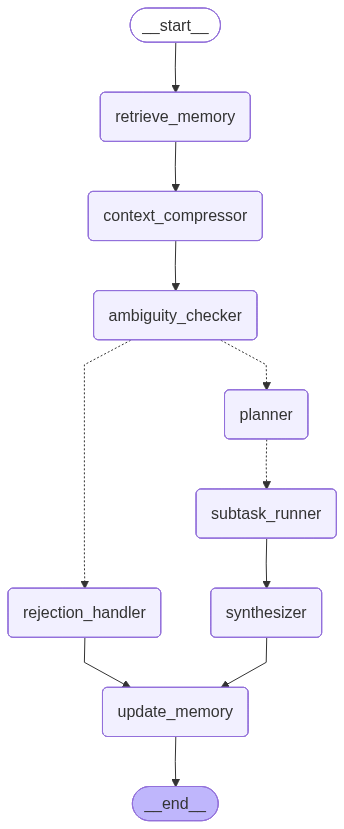

In [9]:
graph